In [ ]:
from astropy.table import Table
from matplotlib import pyplot as plt
import os
import pandas as pd
import pathlib

In [4]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [ ]:
reportable = pd.read_csv('(#path to#)reportable.csv', index_col='Unnamed: 0')

In [7]:
reportable['bp-rp'] = reportable['phot_bp_mean_mag']-reportable['phot_rp_mean_mag']

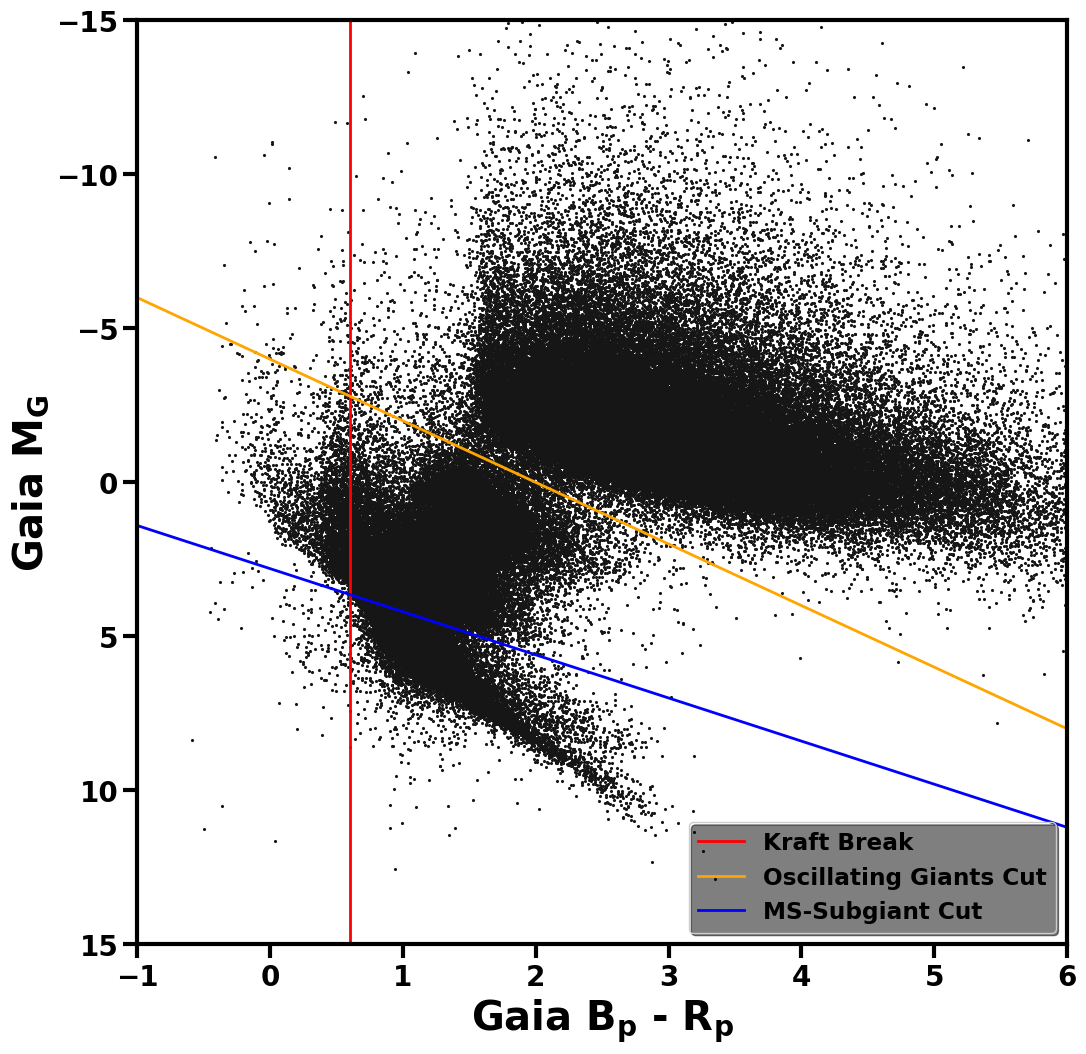

In [30]:
fig, axs = plt.subplots(1, 1, figsize=(12, 12))

axs.set_xlim(-1, 6)
axs.set_ylim(15, -15)
axs.set_xlabel(f'Gaia $\\bf B_p$ - $\\bf R_p$', weight='bold')
axs.set_ylabel(f'Gaia $\\bf M_G$', weight='bold')
axs.plot([0.6, 0.6], [15, -15], 'r', label="Kraft Break", rasterized=True, linewidth=2)
im2 = axs.scatter('bp-rp', 'abs_g_mag', c="#161616", s=5, data=reportable, label='', linewidths=0.01, rasterized=True)

def graph(formula, x_range, col, lab):  
    x = np.array(x_range)  
    y = formula(x) 
    axs.plot(x, y, col, label=lab, rasterized=True, linewidth=2)


def my_formula_oscillators(x):
    return (2*x)-4
    
def my_formula_subgiants(x):
    return ((7/5)*x)+(14/5)

graph(my_formula_oscillators, range(-2, 8), 'orange', lab='Oscillating Giants Cut')
graph(my_formula_subgiants, range(-2, 8), 'b', lab='MS-Subgiant Cut')

plt.legend(loc='lower right', shadow=True, fontsize='small')
plt.savefig('hrsubpopulations.pdf',  dpi=300)
plt.show()